# Onset Classification — Cross-Notebook Results Comparison

This notebook loads the `overall_summary` results from each `onset-classify_*`
notebook directly from the saved `.ipynb` JSON, then compares the important
metrics (`root`, `thirds`, `underseg`, `overseg`) across notebooks and datasets.

Edit `NOTEBOOK_SOURCES` to control which notebooks are included — each entry
maps a short label to the notebook filename. The parser reads the rendered
HTML of the **MIREX** cell (cell index 11) so the data is read directly from
the notebook output, with no need to re-run the training/evaluation pipeline.

## Configuration

In [1]:
from pathlib import Path

ONSET_DIR = Path('/home/seya/code/chord-detection/training/notebooks/onset')

# Map a short label to each notebook file. Add, remove, or rename entries
# here to change which notebooks are included in the comparison.
NOTEBOOK_SOURCES = {
    'annotation':         'onset-classify_annotation.ipynb',
    'annotation_zeropad': 'onset-classify_annotation_zeropad.ipynb',
    'lag=2':              'onset-classify_lag=2.ipynb',
    'spectral-flux':      'onset-classify_spectral-flux.ipynb',
    'superflux':          'onset-classify_superflux.ipynb',
}

# Metrics to compare. All of these are present in the per-notebook
# `overall_summary` DataFrame (cell index 11, output 0).
PRIMARY_METRICS = ['root', 'thirds', 'underseg', 'overseg']

# Datasets, in the order we want them displayed.
DATASET_ORDER = ['normal_sustain', 'broken_sustain', 'normal_no-sustain']

print('Configured sources:')
for label, fname in NOTEBOOK_SOURCES.items():
    print(f'  {label:20s} -> {fname}')

Configured sources:
  annotation           -> onset-classify_annotation.ipynb
  annotation_zeropad   -> onset-classify_annotation_zeropad.ipynb
  lag=2                -> onset-classify_lag=2.ipynb
  spectral-flux        -> onset-classify_spectral-flux.ipynb
  superflux            -> onset-classify_superflux.ipynb


## Load results from notebook JSON

In [2]:
import json
import re
import pandas as pd


def html_table_to_dataframe(html):
    """Parse a rendered pandas HTML table (with an index column) into a DataFrame."""
    if isinstance(html, list):
        html = ''.join(html)
    rows = re.findall(r'<tr[^>]*>(.*?)</tr>', html, re.DOTALL)
    parsed = []
    for r in rows:
        cells = re.findall(r'<t[hd][^>]*>(.*?)</t[hd]>', r, re.DOTALL)
        cleaned = [re.sub(r'<[^>]+>', '', c).strip() for c in cells]
        parsed.append(cleaned)
    if not parsed:
        return None
    header, body = parsed[0], parsed[1:]
    # Drop the leading empty header cell that pandas uses for the index.
    if header and header[0] == '':
        header = header[1:]
        body = [r[1:] for r in body]
    return pd.DataFrame(body, columns=header)


def load_overall_summary(notebook_path, cell_index=11, output_index=0):
    """Pull the MIREX `overall_summary` DataFrame out of a saved notebook."""
    with open(notebook_path) as fp:
        nb = json.load(fp)
    cell = nb['cells'][cell_index]
    outputs = cell.get('outputs', [])
    if output_index >= len(outputs):
        raise IndexError(
            f'{notebook_path.name}: cell {cell_index} has {len(outputs)} '
            f'outputs, requested output {output_index}'
        )
    out = outputs[output_index]
    html = out['data'].get('text/html')
    if html is None:
        raise ValueError(
            f'{notebook_path.name}: output {output_index} of cell {cell_index} '
            'has no text/html payload'
        )
    df = html_table_to_dataframe(html)
    # Coerce numeric columns (everything except `dataset`).
    for col in df.columns:
        if col != 'dataset':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


per_source = {}
for label, fname in NOTEBOOK_SOURCES.items():
    path = ONSET_DIR / fname
    df = load_overall_summary(path)
    df['source'] = label
    per_source[label] = df
    print(f'Loaded {label:20s} ({fname}) — shape={df.shape}')

Loaded annotation           (onset-classify_annotation.ipynb) — shape=(3, 18)
Loaded annotation_zeropad   (onset-classify_annotation_zeropad.ipynb) — shape=(3, 18)
Loaded lag=2                (onset-classify_lag=2.ipynb) — shape=(3, 18)
Loaded spectral-flux        (onset-classify_spectral-flux.ipynb) — shape=(3, 18)
Loaded superflux            (onset-classify_superflux.ipynb) — shape=(3, 18)


## Per-source raw tables

In [3]:
from IPython.display import display

for label, df in per_source.items():
    print(f'### {label}  ({NOTEBOOK_SOURCES[label]})')
    display(df.round(4))
    print()

### annotation  (onset-classify_annotation.ipynb)


,dataset,thirds,thirds_inv,triads,triads_inv,tetrads,tetrads_inv,root,mirex,majmin,majmin_inv,sevenths,sevenths_inv,underseg,overseg,seg,total_duration,source
0,normal_sustain,0.9572,0.9572,0.9572,0.9572,0.9572,0.9572,0.9572,0.9572,0.9636,0.9636,0.9636,0.9636,1.0000,1.0000,1.0000,119.2213,annotation
1,broken_sustain,0.9210,0.9210,0.8999,0.8999,0.8999,0.8999,0.9361,0.8999,0.9033,0.9033,0.9033,0.9033,0.9963,1.0000,0.9963,408.6933,annotation
2,normal_no-sustain,0.9889,0.9889,0.9851,0.9851,0.9851,0.9851,0.9889,0.9851,0.9833,0.9833,0.9833,0.9833,1.0000,0.9984,0.9984,610.7947,annotation



### annotation_zeropad  (onset-classify_annotation_zeropad.ipynb)


,dataset,thirds,thirds_inv,triads,triads_inv,tetrads,tetrads_inv,root,mirex,majmin,majmin_inv,sevenths,sevenths_inv,underseg,overseg,seg,total_duration,source
0,normal_sustain,0.8462,0.8462,0.8278,0.8278,0.8278,0.8278,0.8670,0.8278,0.8280,0.8280,0.8280,0.8280,0.9700,0.9898,0.9597,119.2213,annotation_zeropad
1,broken_sustain,0.9100,0.9100,0.8889,0.8889,0.8889,0.8889,0.9209,0.8889,0.8989,0.8989,0.8989,0.8989,0.9963,0.9967,0.9930,408.6933,annotation_zeropad
2,normal_no-sustain,0.9622,0.9622,0.9565,0.9565,0.9565,0.9565,0.9659,0.9565,0.9565,0.9565,0.9565,0.9565,1.0000,0.9951,0.9951,610.7947,annotation_zeropad



### lag=2  (onset-classify_lag=2.ipynb)


,dataset,thirds,thirds_inv,triads,triads_inv,tetrads,tetrads_inv,root,mirex,majmin,majmin_inv,sevenths,sevenths_inv,underseg,overseg,seg,total_duration,source
0,normal_sustain,0.9350,0.9350,0.9350,0.9350,0.9350,0.9350,0.9364,0.9350,0.9418,0.9418,0.9418,0.9418,0.7044,0.9974,0.7044,119.2213,lag=2
1,broken_sustain,0.8945,0.8945,0.8736,0.8736,0.8736,0.8736,0.9087,0.8736,0.8888,0.8888,0.8888,0.8888,0.7385,0.9868,0.7385,408.6933,lag=2
2,normal_no-sustain,0.9228,0.9228,0.9195,0.9195,0.9195,0.9195,0.9263,0.9195,0.9199,0.9199,0.9199,0.9199,0.7366,0.9882,0.7366,610.7947,lag=2



### spectral-flux  (onset-classify_spectral-flux.ipynb)


,dataset,thirds,thirds_inv,triads,triads_inv,tetrads,tetrads_inv,root,mirex,majmin,majmin_inv,sevenths,sevenths_inv,underseg,overseg,seg,total_duration,source
0,normal_sustain,0.9072,0.9072,0.9072,0.9072,0.9072,0.9072,0.9113,0.9072,0.9103,0.9103,0.9103,0.9103,0.7104,0.9860,0.7104,119.2213,spectral-flux
1,broken_sustain,0.8007,0.8007,0.7835,0.7835,0.7835,0.7835,0.8224,0.7835,0.7994,0.7994,0.7994,0.7994,0.7787,0.9502,0.7782,408.6933,spectral-flux
2,normal_no-sustain,0.8211,0.8211,0.8147,0.8147,0.8147,0.8147,0.8303,0.8147,0.8145,0.8145,0.8145,0.8145,0.7734,0.9519,0.7734,610.7947,spectral-flux



### superflux  (onset-classify_superflux.ipynb)


,dataset,thirds,thirds_inv,triads,triads_inv,tetrads,tetrads_inv,root,mirex,majmin,majmin_inv,sevenths,sevenths_inv,underseg,overseg,seg,total_duration,source
0,normal_sustain,0.9335,0.9335,0.9335,0.9335,0.9335,0.9335,0.9347,0.9335,0.9399,0.9399,0.9399,0.9399,0.7044,0.9975,0.7044,119.2213,superflux
1,broken_sustain,0.8635,0.8635,0.8433,0.8433,0.8433,0.8433,0.8844,0.8433,0.8541,0.8541,0.8541,0.8541,0.7606,0.9750,0.7606,408.6933,superflux
2,normal_no-sustain,0.8540,0.8540,0.8500,0.8500,0.8500,0.8500,0.8607,0.8500,0.8490,0.8490,0.8490,0.8490,0.7745,0.9704,0.7745,610.7947,superflux


## Combined long-format table

In [4]:
# Stack all notebooks into a single long-format table and force consistent
# dataset ordering.
combined = pd.concat(per_source.values(), ignore_index=True)
combined['dataset'] = pd.Categorical(
    combined['dataset'], categories=DATASET_ORDER, ordered=True
)
combined = combined.sort_values(['dataset', 'source']).reset_index(drop=True)

# Keep the full table available, but show a focused view first.
focus_columns = ['source', 'dataset', *PRIMARY_METRICS]
focus = combined[focus_columns].copy()
print('Combined long-format table (focused metrics):')
display(focus.round(4))

Combined long-format table (focused metrics):


,source,dataset,root,thirds,underseg,overseg
0,annotation,normal_sustain,0.9572,0.9572,1.0000,1.0000
1,annotation_zeropad,normal_sustain,0.8670,0.8462,0.9700,0.9898
2,lag=2,normal_sustain,0.9364,0.9350,0.7044,0.9974
3,spectral-flux,normal_sustain,0.9113,0.9072,0.7104,0.9860
4,superflux,normal_sustain,0.9347,0.9335,0.7044,0.9975
5,annotation,broken_sustain,0.9361,0.9210,0.9963,1.0000
6,annotation_zeropad,broken_sustain,0.9209,0.9100,0.9963,0.9967
7,lag=2,broken_sustain,0.9087,0.8945,0.7385,0.9868
8,spectral-flux,broken_sustain,0.8224,0.8007,0.7787,0.9502
9,superflux,broken_sustain,0.8844,0.8635,0.7606,0.9750


## Wide-format comparison: rows = dataset, columns = (source × metric)

In [5]:
# Pivot so that each row is a dataset and each column is a (source, metric)
# pair. This makes the per-source deltas easy to read off.
wide = combined.pivot_table(
    index='dataset',
    columns='source',
    values=PRIMARY_METRICS,
).round(4)

# Re-order the column levels so PRIMARY_METRICS stays first then sources.
wide = wide.reindex(columns=PRIMARY_METRICS, level=0)
wide = wide.reindex(columns=list(NOTEBOOK_SOURCES.keys()), level=1)
wide = wide.reindex(index=DATASET_ORDER)

print('Wide-format comparison (dataset x source x metric):')
display(wide)

Wide-format comparison (dataset x source x metric):


/tmp/ipykernel_431907/3041719065.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  wide = combined.pivot_table(


root                                           \
source            annotation annotation_zeropad   lag=2 spectral-flux   
dataset                                                                 
normal_sustain        0.9572             0.8670  0.9364        0.9113   
broken_sustain        0.9361             0.9209  0.9087        0.8224   
normal_no-sustain     0.9889             0.9659  0.9263        0.8303   

                                thirds                             \
source            superflux annotation annotation_zeropad   lag=2   
dataset                                                             
normal_sustain       0.9347     0.9572             0.8462  0.9350   
broken_sustain       0.8844     0.9210             0.9100  0.8945   
normal_no-sustain    0.8607     0.9889             0.9622  0.9228   

                                            underseg                     \
source            spectral-flux superflux annotation annotation_zeropad   
dataset                                                                   
normal_sustain           0.9072    0.9335     1.0000             0.9700   
broken_sustain           0.8007    0.8635     0.9963             0.9963   
normal_no-sustain        0.8211    0.8540     1.0000             1.0000   

                                                     overseg  \
source              lag=2 spectral-flux superflux annotation   
dataset                                                        
normal_sustain     0.7044        0.7104    0.7044     1.0000   
broken_sustain     0.7385        0.7787    0.7606     1.0000   
normal_no-sustain  0.7366        0.7734    0.7745     0.9984   

                                                                      
source            annotation_zeropad   lag=2 spectral-flux superflux  
dataset                                                               
normal_sustain                0.9898  0.9974        0.9860    0.9975  
broken_sustain                0.9967  0.9868        0.9502    0.9750  
normal_no-sustain             0.9951  0.9882        0.9519    0.9704

## Per-metric best source

In [6]:
# For classification metrics (root, thirds) higher is better. For
# overseg higher is also better (less over-segmentation). For underseg
# higher is also better (fewer missed boundaries). All four metrics share
# the same "higher is better" convention so we can use idxmax directly.
rank_records = []
for metric in PRIMARY_METRICS:
    sub = wide.xs(metric, axis=1, level=0)
    for dataset in sub.index:
        row = sub.loc[dataset].dropna()
        if row.empty:
            continue
        best = row.idxmax()
        worst = row.idxmin()
        rank_records.append({
            'metric': metric,
            'dataset': dataset,
            'best_source': best,
            'best_value': round(float(row[best]), 4),
            'worst_source': worst,
            'worst_value': round(float(row[worst]), 4),
            'range': round(float(row[best] - row[worst]), 4),
        })
ranking = pd.DataFrame(rank_records)
ranking['dataset'] = pd.Categorical(
    ranking['dataset'], categories=DATASET_ORDER, ordered=True
)
ranking = ranking.sort_values(['metric', 'dataset']).reset_index(drop=True)
display(ranking)

,metric,dataset,best_source,best_value,worst_source,worst_value,range
0,overseg,normal_sustain,annotation,1.0000,spectral-flux,0.9860,0.0140
1,overseg,broken_sustain,annotation,1.0000,spectral-flux,0.9502,0.0498
2,overseg,normal_no-sustain,annotation,0.9984,spectral-flux,0.9519,0.0465
3,root,normal_sustain,annotation,0.9572,annotation_zeropad,0.8670,0.0902
4,root,broken_sustain,annotation,0.9361,spectral-flux,0.8224,0.1137
5,root,normal_no-sustain,annotation,0.9889,spectral-flux,0.8303,0.1586
6,thirds,normal_sustain,annotation,0.9572,annotation_zeropad,0.8462,0.1110
7,thirds,broken_sustain,annotation,0.9210,spectral-flux,0.8007,0.1203
8,thirds,normal_no-sustain,annotation,0.9889,spectral-flux,0.8211,0.1678
9,underseg,normal_sustain,annotation,1.0000,lag=2,0.7044,0.2956


## Bar plots — one figure per metric, grouped by dataset

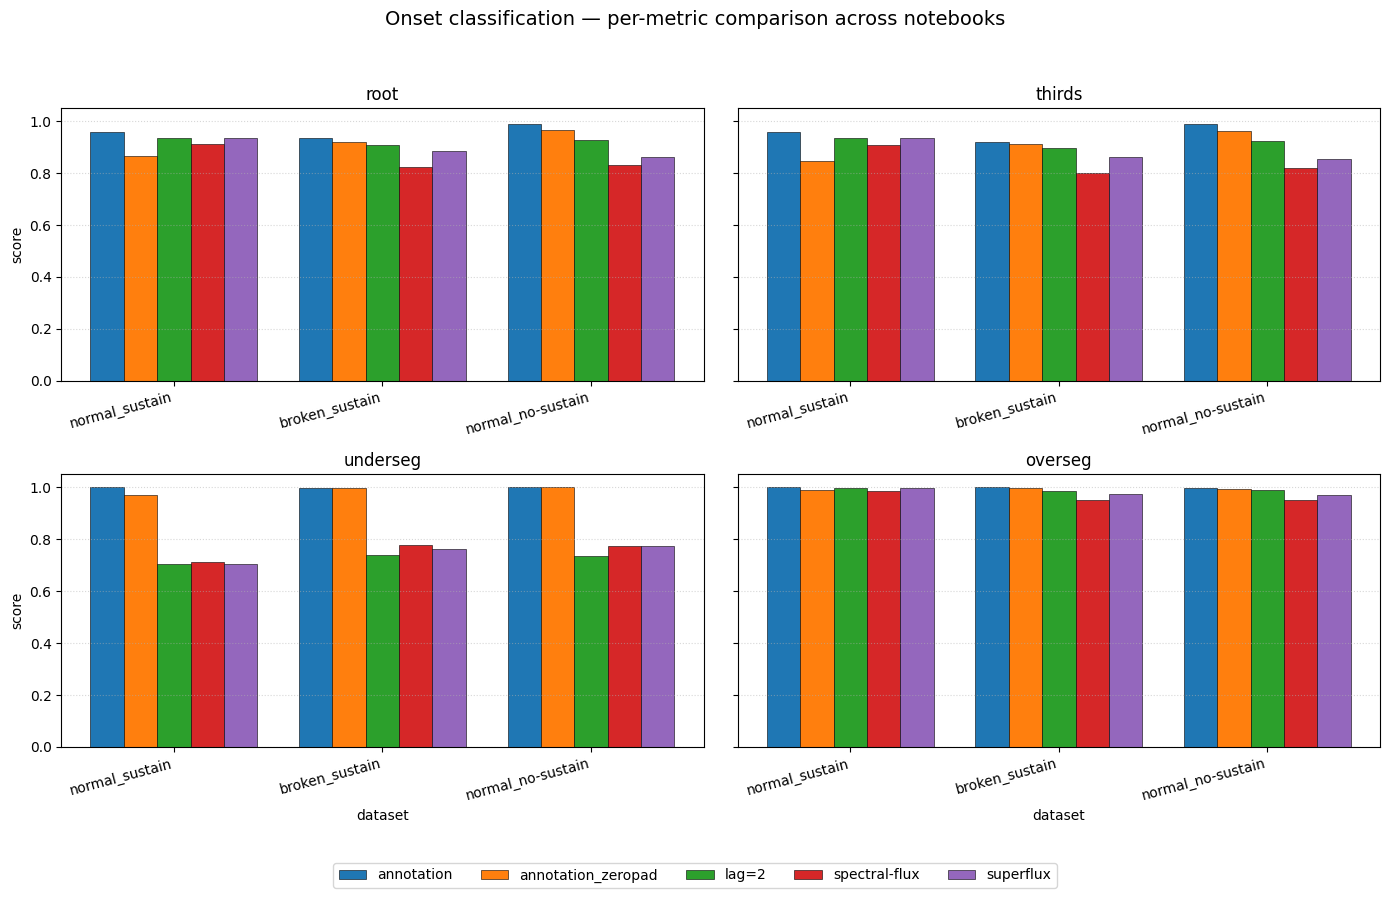

In [7]:
import matplotlib.pyplot as plt
import numpy as np

source_labels = list(NOTEBOOK_SOURCES.keys())
n_sources = len(source_labels)
n_datasets = len(DATASET_ORDER)
bar_width = 0.8 / n_sources
x = np.arange(n_datasets)

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
axes = axes.ravel()
palette = plt.get_cmap('tab10').colors

for ax, metric in zip(axes, PRIMARY_METRICS):
    for i, label in enumerate(source_labels):
        try:
            values = wide.xs(metric, axis=1, level=0)[label].reindex(DATASET_ORDER).values
        except KeyError:
            continue
        offset = (i - (n_sources - 1) / 2) * bar_width
        ax.bar(
            x + offset,
            values,
            width=bar_width,
            label=label,
            color=palette[i % len(palette)],
            edgecolor='black',
            linewidth=0.4,
        )
    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(DATASET_ORDER, rotation=15, ha='right')
    ax.set_ylim(0.0, 1.05)
    ax.grid(axis='y', linestyle=':', alpha=0.5)

for ax in axes[-2:]:
    ax.set_xlabel('dataset')
for ax in axes[::2]:
    ax.set_ylabel('score')

fig.suptitle('Onset classification — per-metric comparison across notebooks', fontsize=14)
fig.legend(source_labels, loc='upper center', bbox_to_anchor=(0.5, 0.04), ncol=min(5, n_sources))
fig.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

## Heatmap — single figure, metric × source × dataset

/tmp/ipykernel_431907/1296318418.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


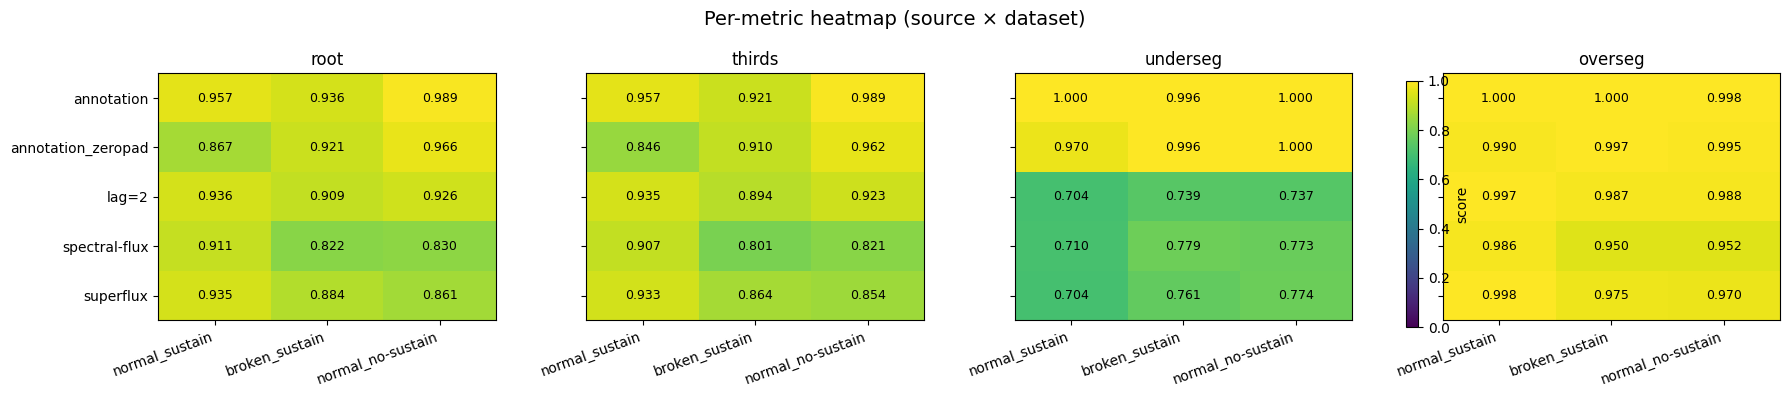

In [8]:
# Build a long table (metric, source, dataset, value) and reshape it for
# a single grouped heatmap.
heatmap_long = combined.melt(
    id_vars=['source', 'dataset'],
    value_vars=PRIMARY_METRICS,
    var_name='metric',
    value_name='score',
).dropna(subset=['score'])

fig, axes = plt.subplots(1, len(PRIMARY_METRICS), figsize=(4.5 * len(PRIMARY_METRICS), 4), sharey=True)
if len(PRIMARY_METRICS) == 1:
    axes = [axes]
vmin, vmax = 0.0, 1.0
for ax, metric in zip(axes, PRIMARY_METRICS):
    sub = heatmap_long[heatmap_long['metric'] == metric]
    pivot = (
        sub.pivot(index='source', columns='dataset', values='score')
        .reindex(index=source_labels, columns=DATASET_ORDER)
    )
    im = ax.imshow(pivot.values, aspect='auto', vmin=vmin, vmax=vmax, cmap='viridis')
    ax.set_xticks(range(len(DATASET_ORDER)))
    ax.set_xticklabels(DATASET_ORDER, rotation=20, ha='right')
    ax.set_yticks(range(len(source_labels)))
    ax.set_yticklabels(source_labels)
    ax.set_title(metric)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if np.isnan(v):
                continue
            ax.text(
                j, i, f'{v:.3f}',
                ha='center', va='center',
                color='white' if v < (vmin + vmax) / 2 else 'black',
                fontsize=9,
            )
fig.colorbar(im, ax=axes, shrink=0.8, label='score')
fig.suptitle('Per-metric heatmap (source × dataset)', fontsize=14)
fig.tight_layout()
plt.show()

## Delta vs. chosen reference notebook

Reference notebook for delta plot: annotation


,metric,source,dataset,reference_value,value,delta_vs_ref
0,overseg,annotation_zeropad,normal_sustain,1.0000,0.9898,-0.0102
1,overseg,annotation_zeropad,broken_sustain,1.0000,0.9967,-0.0033
2,overseg,annotation_zeropad,normal_no-sustain,0.9984,0.9951,-0.0033
3,overseg,lag=2,normal_sustain,1.0000,0.9974,-0.0026
4,overseg,lag=2,broken_sustain,1.0000,0.9868,-0.0132
5,overseg,lag=2,normal_no-sustain,0.9984,0.9882,-0.0102
6,overseg,spectral-flux,normal_sustain,1.0000,0.9860,-0.0140
7,overseg,spectral-flux,broken_sustain,1.0000,0.9502,-0.0498
8,overseg,spectral-flux,normal_no-sustain,0.9984,0.9519,-0.0465
9,overseg,superflux,normal_sustain,1.0000,0.9975,-0.0025


/tmp/ipykernel_431907/3603382096.py:34: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  delta_pivot = deltas.pivot_table(


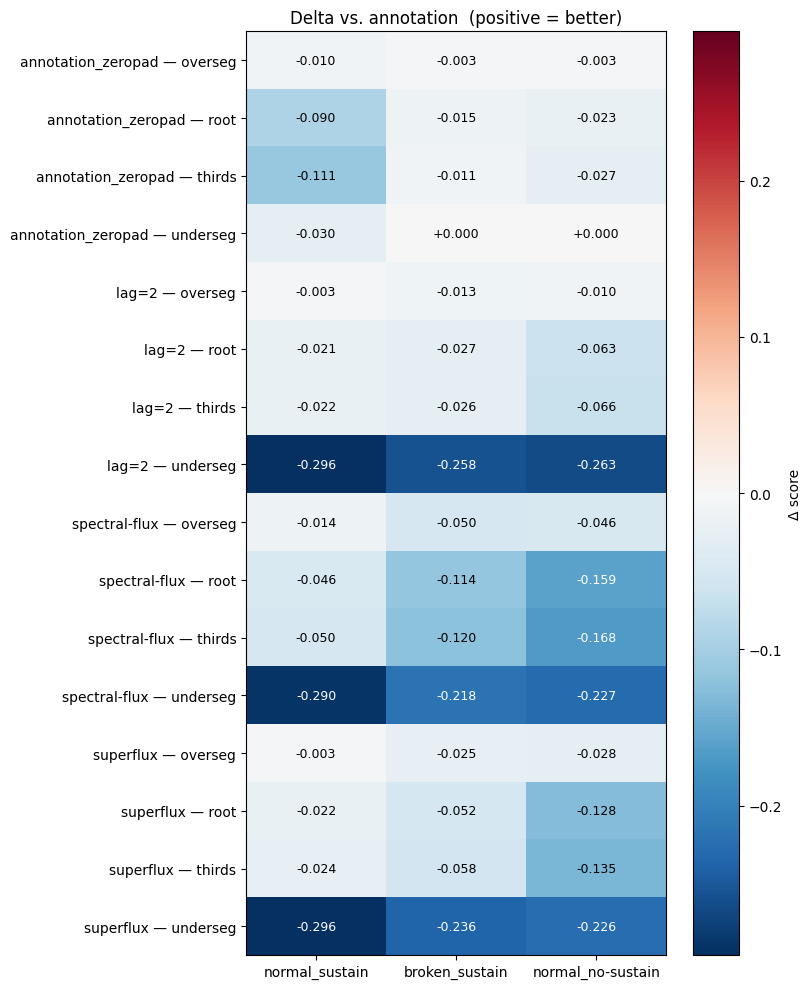

In [9]:
# Pick a reference notebook (defaults to the first entry of NOTEBOOK_SOURCES)
# and show the signed difference of every other source vs. it. Useful to
# highlight where each variant wins or loses.
REFERENCE_SOURCE = list(NOTEBOOK_SOURCES.keys())[0]
print(f'Reference notebook for delta plot: {REFERENCE_SOURCE}')

delta_records = []
for metric in PRIMARY_METRICS:
    sub = wide.xs(metric, axis=1, level=0)
    for source in source_labels:
        if source == REFERENCE_SOURCE:
            continue
        for dataset in DATASET_ORDER:
            ref = sub.loc[dataset, REFERENCE_SOURCE]
            cur = sub.loc[dataset, source]
            if pd.isna(ref) or pd.isna(cur):
                continue
            delta_records.append({
                'metric': metric,
                'source': source,
                'dataset': dataset,
                'reference_value': round(float(ref), 4),
                'value': round(float(cur), 4),
                'delta_vs_ref': round(float(cur - ref), 4),
            })
deltas = pd.DataFrame(delta_records)
deltas['dataset'] = pd.Categorical(
    deltas['dataset'], categories=DATASET_ORDER, ordered=True
)
deltas = deltas.sort_values(['metric', 'source', 'dataset']).reset_index(drop=True)
display(deltas)

# Visualise the deltas as a heatmap (positive = better than reference).
delta_pivot = deltas.pivot_table(
    index=['source', 'metric'],
    columns='dataset',
    values='delta_vs_ref',
).reindex(columns=DATASET_ORDER)
vmax = float(np.nanmax(np.abs(delta_pivot.values))) if not delta_pivot.empty else 1.0
vmax = max(vmax, 1e-6)
fig, ax = plt.subplots(figsize=(8, 0.5 * len(delta_pivot) + 2))
im = ax.imshow(delta_pivot.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(DATASET_ORDER)))
ax.set_xticklabels(DATASET_ORDER)
ax.set_yticks(range(len(delta_pivot)))
ax.set_yticklabels([f'{s} — {m}' for s, m in delta_pivot.index])
for i in range(delta_pivot.shape[0]):
    for j in range(delta_pivot.shape[1]):
        v = delta_pivot.values[i, j]
        if np.isnan(v):
            continue
        ax.text(
            j, i, f'{v:+.3f}',
            ha='center', va='center',
            color='white' if abs(v) > vmax * 0.5 else 'black',
            fontsize=9,
        )
ax.set_title(f'Delta vs. {REFERENCE_SOURCE}  (positive = better)')
fig.colorbar(im, ax=ax, label='Δ score')
fig.tight_layout()
plt.show()